In [ ]:
"""
Plots performance metrics (profile Pearson correlation, profile Jensen-Shannon distance, log counts Pearson correlation, counts Spearman correlation) as a function of read depth
"""

In [35]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt

In [36]:
def get_metrics(metric_path):
    with open(metric_path, 'r') as f:
        metrics = json.load(f)
    return metrics

In [37]:
reads = pd.read_csv("../configs/n_reads.txt", sep="\t")

In [38]:
metrics = {
    exp_id: get_metrics(f"../performance_metrics/bpnet/{exp_id}.json") for exp_id in reads.experiment
}

In [39]:
profile_jsd = pd.DataFrame(
    {
        exp_id: [x["profile_jsd"] for x in metrics[exp_id]["per_fold"].values()]
        for exp_id in metrics
    }
)
counts_pearson = pd.DataFrame(
    {
        exp_id: [x["log_counts_pearson"] for x in metrics[exp_id]["per_fold"].values()]
        for exp_id in metrics
    }
)
profile_jsd

,ENCSR882DWM,ENCSR114HGS,ENCSR165QKR,ENCSR197JLW,ENCSR100EDZ,ENCSR273ORE,ENCSR124RWD,ENCSR178XKL,ENCSR720EXP,ENCSR753TEA,...,ENCSR353JON,ENCSR374OGG,ENCSR528FMA,ENCSR500IHG,ENCSR098LLB,ENCSR046BCI,ENCSR935RNW,ENCSR799DGV,ENCSR261KBX,ENCSR100LIJ
0,0.457619,0.442002,0.296802,0.342996,0.317506,0.303319,0.354160,0.345441,0.334572,0.368058,...,0.442117,0.354383,0.339085,0.341930,0.330242,0.342380,0.327730,0.331032,0.340460,0.311704
1,0.454430,0.467403,0.287470,0.328853,0.307636,0.290130,0.349532,0.351694,0.337969,0.368890,...,0.464374,0.356594,0.346509,0.349837,0.328327,0.348265,0.318901,0.329572,0.324969,0.317692
2,0.449021,0.447259,0.301773,0.339741,0.319880,0.305072,0.355492,0.345959,0.340779,0.361337,...,0.456285,0.354781,0.347790,0.349119,0.327903,0.348680,0.329179,0.333725,0.340749,0.328733
3,0.449319,0.451708,0.300019,0.332275,0.308929,0.298110,0.351853,0.343776,0.345827,0.360362,...,0.459319,0.360512,0.345695,0.344992,0.328149,0.342313,0.332233,0.327642,0.330340,0.316186
4,0.446725,0.444978,0.297601,0.335432,0.315629,0.306298,0.354481,0.350341,0.341555,0.360933,...,0.453949,0.358446,0.347746,0.354748,0.327533,0.339612,0.328461,0.325394,0.342565,0.322708
5,0.464452,0.463838,0.290520,0.332787,0.309588,0.300688,0.351242,0.340795,0.341789,0.364322,...,0.452847,0.359244,0.346135,0.350423,0.327603,0.339823,0.323596,0.322119,0.330677,0.312544
6,0.458172,0.461045,0.287572,0.332124,0.314168,0.301019,0.337301,0.337260,0.346425,0.350959,...,0.449854,0.353524,0.339196,0.345700,0.319224,0.324392,0.310335,0.313486,0.324560,0.305688


In [42]:
reads.index = reads.experiment
reads["profile_jsd"] = profile_jsd.mean(axis=0)
#reads["1-profile_jsd"] = 1 - profile_jsd.mean(axis=0)
reads["log_counts_pearson"] = counts_pearson.mean(axis=0)
reads.to_csv("../performance_metrics/bpnet/procap-atlas_performance_metrics.tsv", sep="\t", index=False)

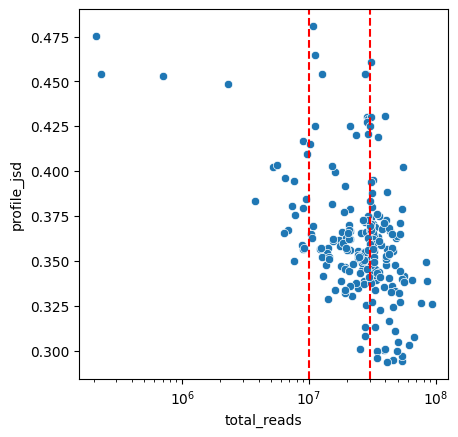

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=reads, x="total_reads", y="profile_jsd")
plt.xscale("log")
ax.set_box_aspect(1)
ax.axvline(1e7, color="red", linestyle="dashed")
#ax.axvline(2e7, color="red", linestyle="dashed")
ax.axvline(3e7, color="red", linestyle="dashed")

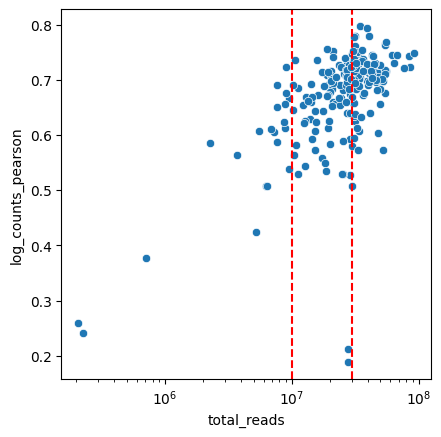

In [10]:
# Make square
fig, ax = plt.subplots()
sns.scatterplot(data=reads, x="total_reads", y="log_counts_pearson")
plt.xscale("log")
ax.set_box_aspect(1)
ax.axvline(1e7, color="red", linestyle="dashed")
#ax.axvline(2e7, color="red", linestyle="dashed")
ax.axvline(3e7, color="red", linestyle="dashed")
#plt.axis('square')

In [108]:
pearsonr(np.log1p(reads["total_reads"]), reads["profile_jsd"])

PearsonRResult(statistic=-0.500314090594829, pvalue=1.3646051860838538e-15)

In [92]:
pearsonr(np.log1p(reads["total_reads"]), reads["log_counts_pearson"])

PearsonRResult(statistic=0.6085930699975003, pvalue=4.345138190220188e-24)

In [15]:
(reads["total_reads"] > 2e7).sum()

165

In [161]:
reads[reads["total_reads"] > 3e7]["log_counts_pearson"].mean()

0.7072468715295637

In [186]:
reads[reads.biosample.str.contains("liver")]

,experiment,biosample,pl_reads,mn_reads,total_reads,profile_jsd,log_counts_pearson,1-profile_jsd
experiment,,,,,,,,
ENCSR753TEA,ENCSR753TEA,liver,10521242,10492244,21013486,0.362123,0.660021,0.637877
ENCSR694RPO,ENCSR694RPO,right lobe of liver,15874668,15889142,31763810,0.395220,0.626161,0.604780
ENCSR992HBP,ENCSR992HBP,right lobe of liver,16289889,16234832,32524721,0.364332,0.685660,0.635668
ENCSR575NNF,ENCSR575NNF,right lobe of liver,15695265,15515577,31210842,0.379948,0.657755,0.620052
ENCSR243MVI,ENCSR243MVI,liver,3650765,3659345,7310110,0.380781,0.605032,0.619219
ENCSR331UGM,ENCSR331UGM,liver,25809699,25873850,51683549,0.370871,0.697182,0.629129
ENCSR065QHA,ENCSR065QHA,left lobe of liver,15221015,15064622,30285637,0.383260,0.635495,0.616740
ENCSR072JHG,ENCSR072JHG,liver,15374783,15340261,30715044,0.370106,0.594936,0.629894
ENCSR845LKT,ENCSR845LKT,right lobe of liver,15448618,15367876,30816494,0.460610,0.635559,0.539390


In [34]:
reads

,experiment,biosample,pl_reads,mn_reads,total_reads,profile_jsd,1-profile_jsd,log_counts_pearson
experiment,,,,,,,,
ENCSR882DWM,ENCSR882DWM,K562,14206466,13712815,27919281,0.454248,0.545752,0.188326
ENCSR114HGS,ENCSR114HGS,K562,14050011,13555473,27605484,0.454033,0.545967,0.211919
ENCSR165QKR,ENCSR165QKR,HCT116,23269890,23011302,46281192,0.294537,0.705463,0.714222
ENCSR197JLW,ENCSR197JLW,HCT116,12336819,12177545,24514364,0.334887,0.665113,0.667008
ENCSR100EDZ,ENCSR100EDZ,HCT116,16717966,16451256,33169222,0.313334,0.686666,0.745211
...,...,...,...,...,...,...,...,...
ENCSR046BCI,ENCSR046BCI,A673,18257871,17978342,36236213,0.340781,0.659219,0.715850
ENCSR935RNW,ENCSR935RNW,Calu3,23221800,22848269,46070069,0.324348,0.675652,0.699317
ENCSR799DGV,ENCSR799DGV,MCF 10A,46145728,46257993,92403721,0.326139,0.673861,0.748157


In [ ]:
reads[reads.biosample.str.contains("card")]

,experiment,biosample,pl_reads,mn_reads,total_reads,profile_jsd,log_counts_pearson,1-profile_jsd
experiment,,,,,,,,
ENCSR124RWD,ENCSR124RWD,right ventricle myocardium,14953970,14891106,29845076,0.350580,0.720330,0.649420
ENCSR484CAZ,ENCSR484CAZ,cardiac septum,14777422,14553235,29330657,0.372659,0.703884,0.627341
ENCSR883PPD,ENCSR883PPD,right cardiac atrium,13148884,13051698,26200582,0.348961,0.739618,0.651039
ENCSR294JPW,ENCSR294JPW,left ventricle myocardium,14573483,14480743,29054226,0.355054,0.704367,0.644946
ENCSR571OAW,ENCSR571OAW,mesothelial cell of epicardium,2819612,2728969,5548581,0.403305,0.606897,0.596695
ENCSR270EGA,ENCSR270EGA,left cardiac atrium,9700394,9600925,19301319,0.345671,0.714044,0.654329
ENCSR959JOB,ENCSR959JOB,right ventricle myocardium,14651837,14547991,29199828,0.356310,0.723816,0.643690


In [ ]:
reads[reads.biosample.str.contains("endothelial")]

,experiment,biosample,pl_reads,mn_reads,total_reads,profile_jsd,log_counts_pearson,1-profile_jsd
experiment,,,,,,,,
ENCSR222JNI,ENCSR222JNI,endothelial cell,25656162,25405458,51061620,0.332108,0.700920,0.667892
ENCSR098LLB,ENCSR098LLB,endothelial cell of umbilical vein,15692384,15581835,31274219,0.326997,0.695276,0.673003


In [ ]:
reprogram = pd.DataFrame(
    {
        "total_reads": pd.concat(
            [
                reads[reads.biosample.str.contains("heart")]["total_reads"],
                reads[reads.biosample.str.contains("card")]["total_reads"],
                reads[reads.biosample.str.contains("liver")]["total_reads"],
                reads[reads.biosample.str.contains("endothelial")]["total_reads"]
            ]
        ),
        "log_counts_pearson": pd.concat(
            [
                reads[reads.biosample.str.contains("heart")]["log_counts_pearson"],
                reads[reads.biosample.str.contains("card")]["log_counts_pearson"],
                reads[reads.biosample.str.contains("liver")]["log_counts_pearson"],
                reads[reads.biosample.str.contains("endothelial")]["log_counts_pearson"]
            ]
        ),
        "profile_jsd": pd.concat(
            [
                reads[reads.biosample.str.contains("heart")]["profile_jsd"],
                reads[reads.biosample.str.contains("card")]["profile_jsd"],
                reads[reads.biosample.str.contains("liver")]["profile_jsd"],
                reads[reads.biosample.str.contains("endothelial")]["profile_jsd"]
            ]
        ),
        "category": ["heart"] * 15 + ["liver"] * 10 + ["endothelial"] * 2
    }
)

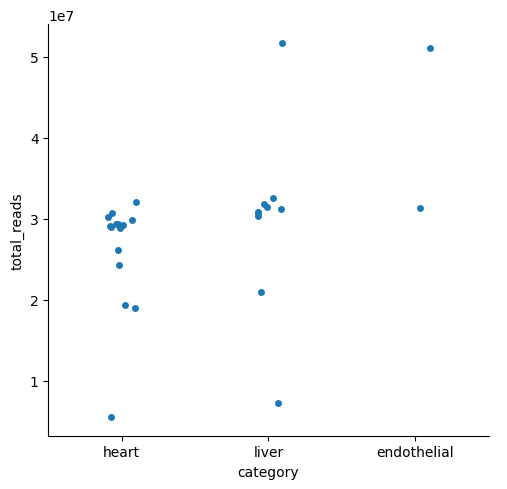

In [31]:
sns.catplot(data=reprogram, x="category", y="total_reads")

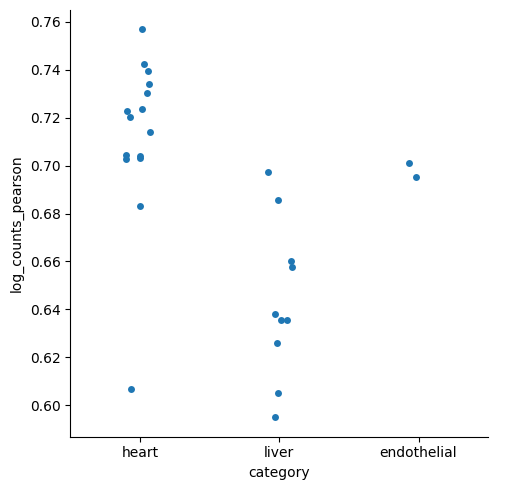

In [32]:
sns.catplot(data=reprogram, x="category", y="log_counts_pearson")

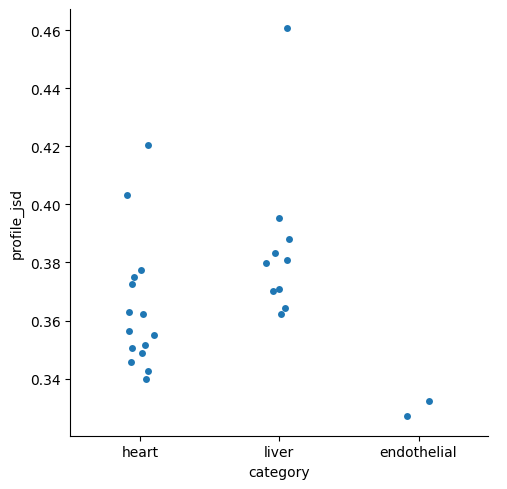

In [33]:
sns.catplot(data=reprogram, x="category", y="profile_jsd")